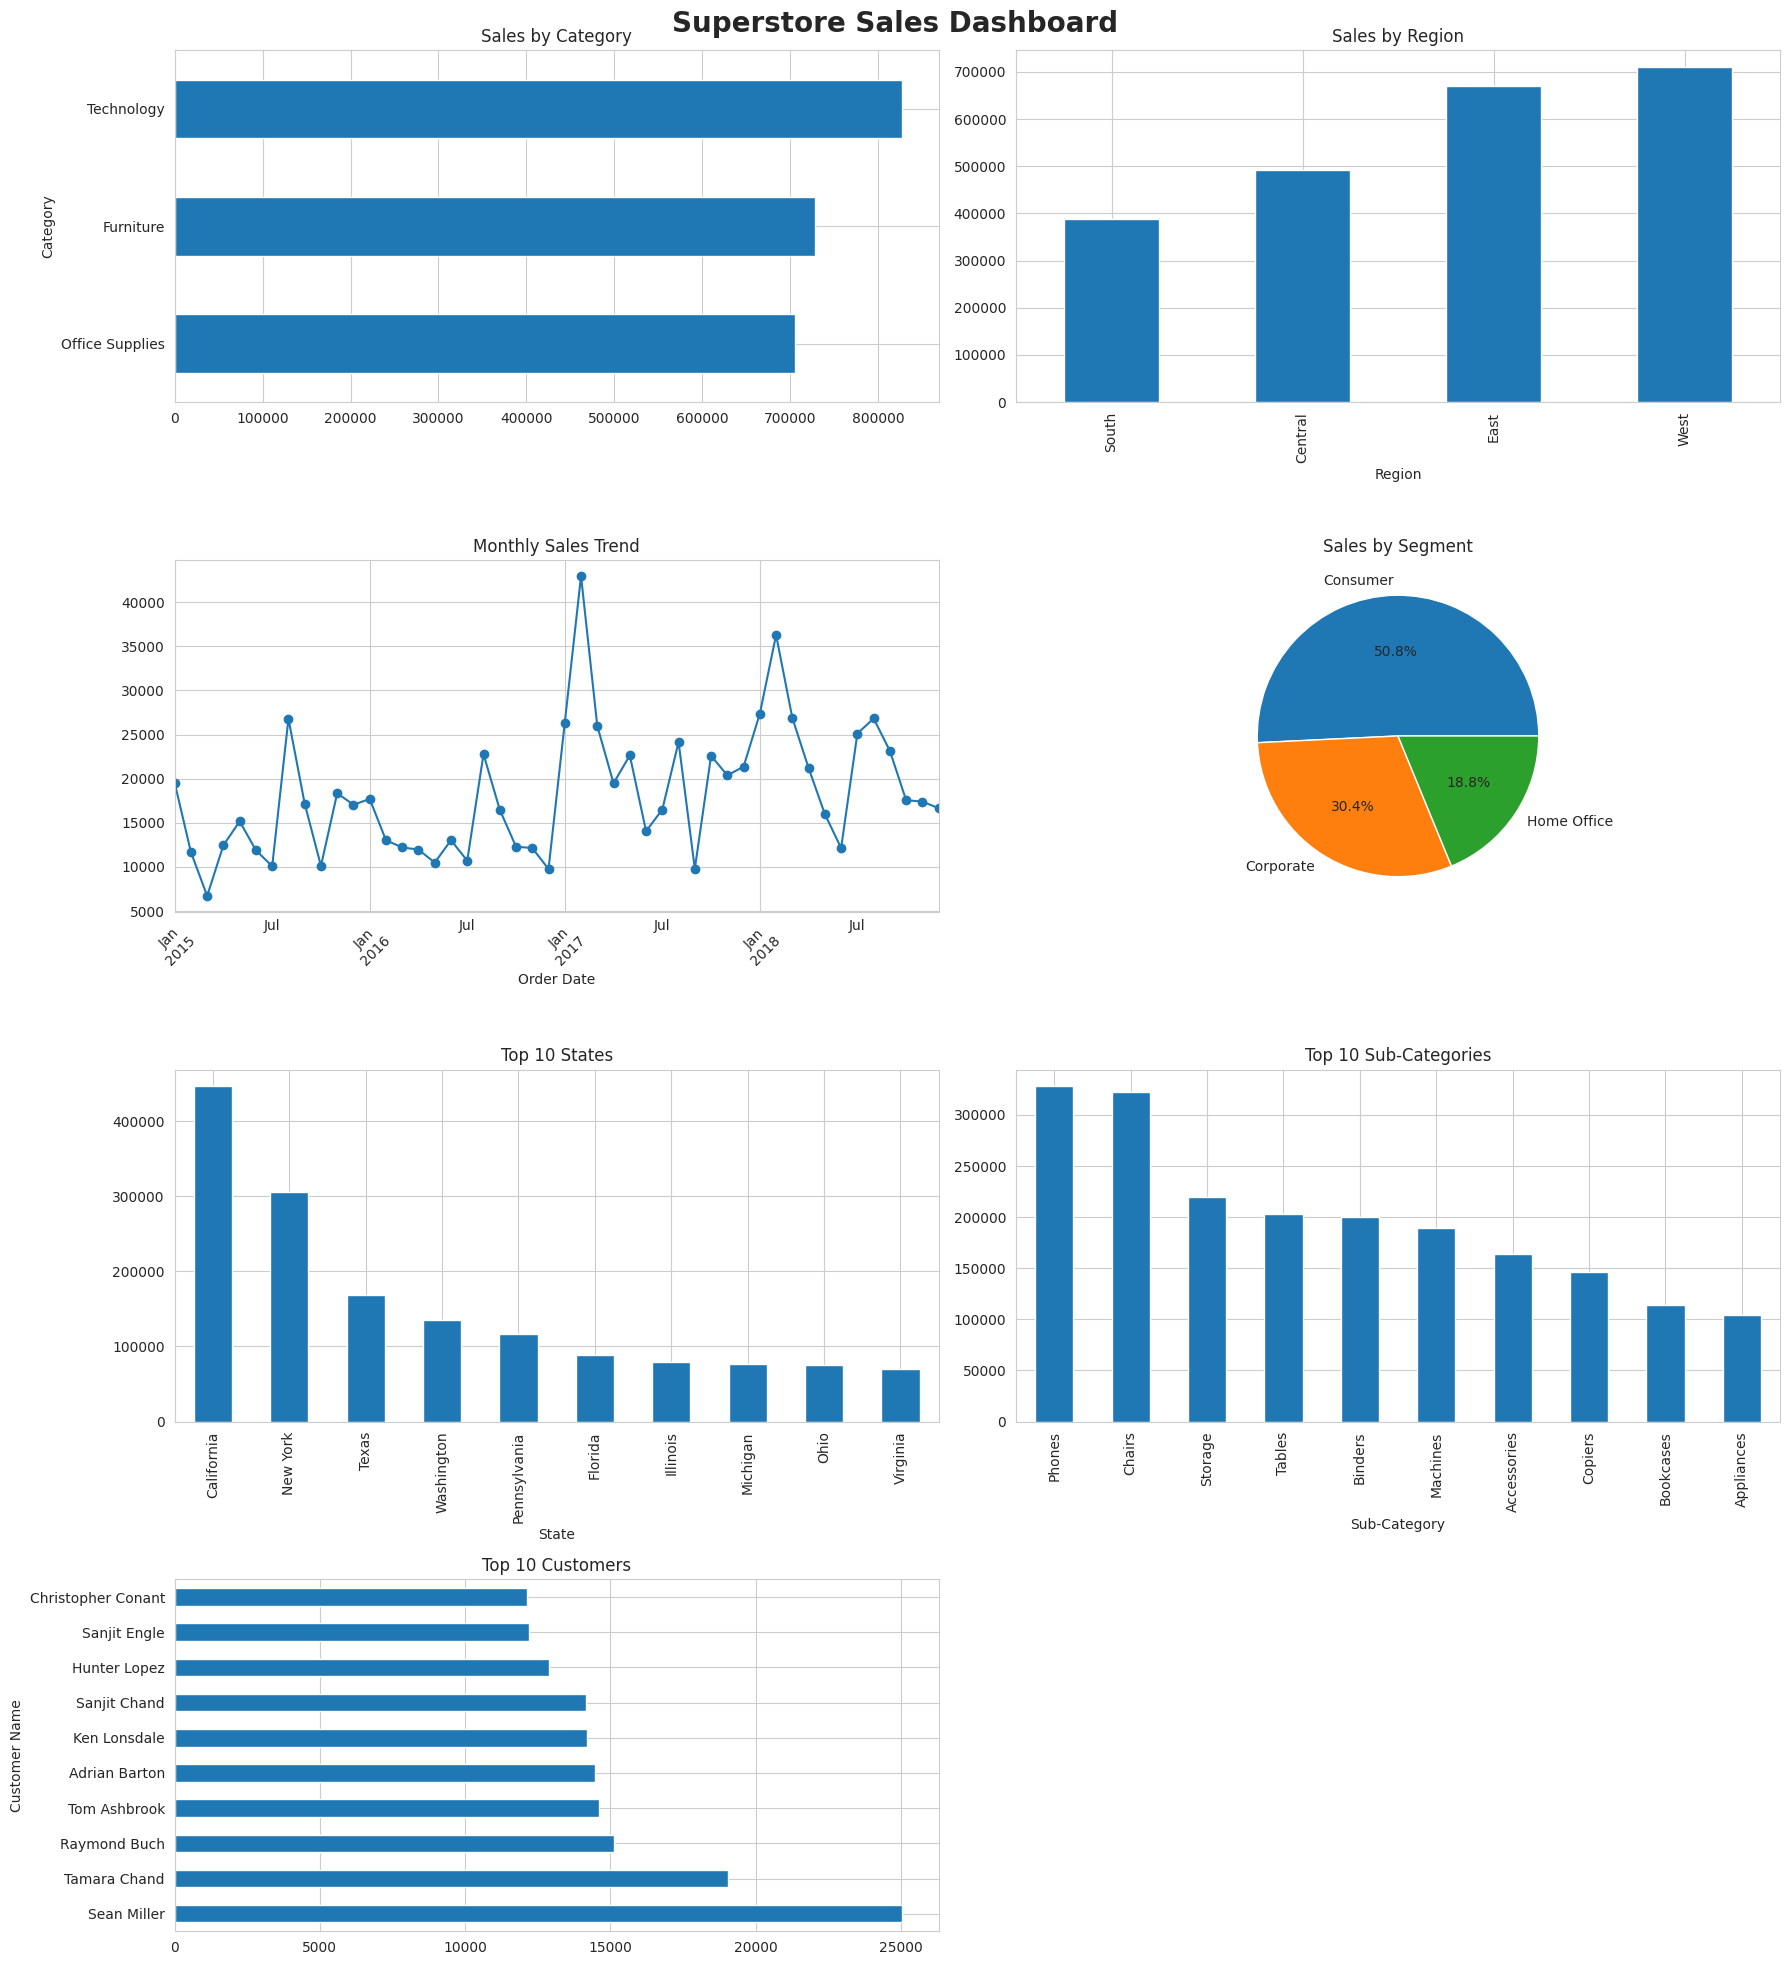


========== SUMMARY ==========
Total Sales   : $2,261,536.78
Total Orders  : 4922
Total Customers : 793

========== KEY INSIGHTS ==========
Top Category : Technology
Top Region   : West
Top State    : California
Top Segment  : Consumer
Top Customer : Sean Miller


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select CSV File - now loading directly from /content/
file_path = '/content/train.csv'

# Load Dataset
df = pd.read_csv(file_path, encoding="latin1")

# Clean Columns
df.columns = df.columns.str.strip()

# Convert Date
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Dashboard Style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 20))

# 1 Sales by Category
plt.subplot(4, 2, 1)
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh')
plt.title("Sales by Category")

# Removed Profit by Category as 'Profit' column is not found
# plt.subplot(4, 2, 2)
# df.groupby('Category')['Profit'].sum().sort_values().plot(kind='barh')
# plt.title("Profit by Category")

# 3 Sales by Region (shifted to position 2)
plt.subplot(4, 2, 2)
df.groupby('Region')['Sales'].sum().sort_values().plot(kind='bar')
plt.title("Sales by Region")

# 4 Monthly Sales Trend (shifted to position 3)
plt.subplot(4, 2, 3)
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)

# 5 Sales by Segment (shifted to position 4)
plt.subplot(4, 2, 4)
df.groupby('Segment')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Sales by Segment")

# 6 Top 10 States (shifted to position 5)
plt.subplot(4, 2, 5)
df.groupby('State')['Sales'].sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind='bar')
plt.title("Top 10 States")

# 7 Top 10 Sub Categories (shifted to position 6)
plt.subplot(4, 2, 6)
df.groupby('Sub-Category')['Sales'].sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind='bar')
plt.title("Top 10 Sub-Categories")

# 8 Top 10 Customers (shifted to position 7)
plt.subplot(4, 2, 7)
df.groupby('Customer Name')['Sales'].sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind='barh')
plt.title("Top 10 Customers")

plt.suptitle(
    "Superstore Sales Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("Superstore_Dashboard.png", dpi=300)
plt.show()

# Summary
print("\n========== SUMMARY ==========")
print(f"Total Sales   : ${df['Sales'].sum():,.2f}")
# Removed Total Profit as 'Profit' column is not found
print(f"Total Orders  : {df['Order ID'].nunique()}")
print(f"Total Customers : {df['Customer Name'].nunique()}")

print("\n========== KEY INSIGHTS ==========")
print("Top Category :", df.groupby('Category')['Sales'].sum().idxmax())
print("Top Region   :", df.groupby('Region')['Sales'].sum().idxmax())
print("Top State    :", df.groupby('State')['Sales'].sum().idxmax())
print("Top Segment  :", df.groupby('Segment')['Sales'].sum().idxmax())
print("Top Customer :", df.groupby('Customer Name')['Sales'].sum().idxmax())


In [ ]:
from google.colab import drive
drive.mount('/content/drive')